In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Looking in links: /usr/share/pip-wheels


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

# Load dataset
df = pd.read_csv("train.csv")
print("Dataset loaded successfully.")

Matplotlib is building the font cache; this may take a moment.


Dataset loaded successfully.


In [3]:
# Dataset dimensions
print("Dataset dimensions (rows, columns):", df.shape)

Dataset dimensions (rows, columns): (891, 12)


In [4]:
# Column names
print("Column names:")
print(df.columns.tolist())

Column names:
['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']


In [5]:
# First five observations
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
# Data types
df.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [7]:
# Detect missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent.round(2)})
missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

,Missing Count,Missing %
Cabin,687,77.10
Age,177,19.87
Embarked,2,0.22


In [8]:
# Handle missing values

# 1. Age: impute with the median age per passenger class (Pclass), since age tends to
#    correlate with class (wealthier/older passengers often traveled in higher classes)
df['Age'] = df.groupby('Pclass')['Age'].transform(lambda x: x.fillna(x.median()))

# 2. Embarked: only 2 missing values -> impute with the mode (most frequent port)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 3. Cabin: over 77% missing, too sparse to impute meaningfully.
#    Instead of dropping the column entirely, create a binary indicator of whether
#    cabin information was recorded, then drop the raw Cabin column.
df['Has_Cabin'] = df['Cabin'].notnull().astype(int)
df.drop(columns=['Cabin'], inplace=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
Has_Cabin      0
dtype: int64


In [9]:
# Detect duplicated observations
duplicate_count = df.duplicated().sum()
print(f"Number of duplicated rows: {duplicate_count}")

Number of duplicated rows: 0


In [10]:
# Remove duplicates if any exist
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicate rows were found; no action needed.")

No duplicate rows were found; no action needed.


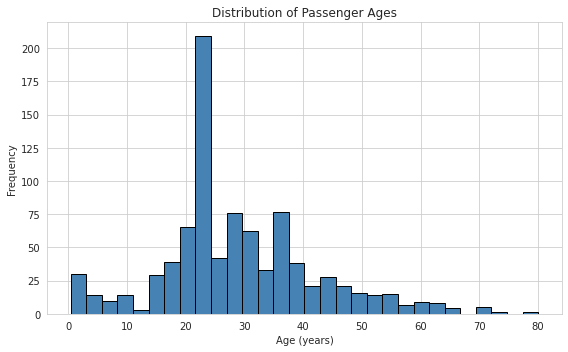

In [11]:
# 1. Histogram of passenger ages
plt.figure(figsize=(8,5))
plt.hist(df['Age'], bins=30, color='steelblue', edgecolor='black')
plt.title('Distribution of Passenger Ages')
plt.xlabel('Age (years)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

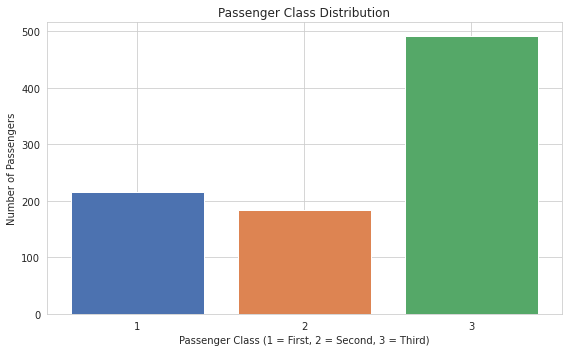

In [12]:
# 2. Bar chart showing passenger class distribution
plt.figure(figsize=(8,5))
class_counts = df['Pclass'].value_counts().sort_index()
plt.bar(class_counts.index.astype(str), class_counts.values, color=['#4C72B0','#DD8452','#55A868'])
plt.title('Passenger Class Distribution')
plt.xlabel('Passenger Class (1 = First, 2 = Second, 3 = Third)')
plt.ylabel('Number of Passengers')
plt.tight_layout()
plt.show()

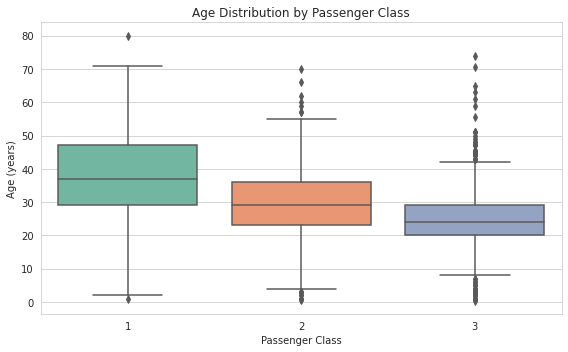

In [13]:
# 3. Boxplot of age by passenger class
plt.figure(figsize=(8,5))
sns.boxplot(x='Pclass', y='Age', data=df, palette='Set2')
plt.title('Age Distribution by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Age (years)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_193/2919260093.py:7: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  plt.colorbar(label='Passenger Class')


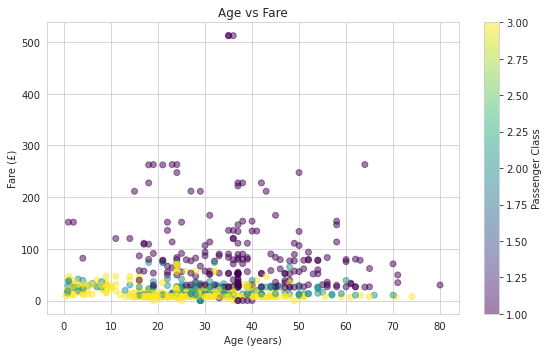

In [14]:
# 4. Scatter plot of Age vs Fare
plt.figure(figsize=(8,5))
plt.scatter(df['Age'], df['Fare'], alpha=0.5, c=df['Pclass'], cmap='viridis')
plt.title('Age vs Fare')
plt.xlabel('Age (years)')
plt.ylabel('Fare (£)')
plt.colorbar(label='Passenger Class')
plt.tight_layout()
plt.show()

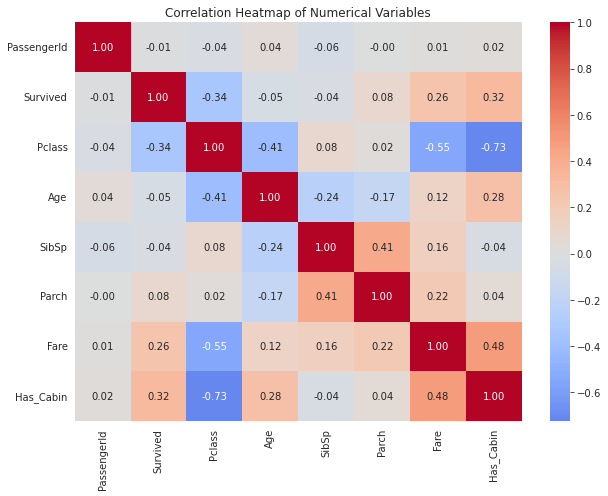

In [15]:
# 5. Correlation heatmap
plt.figure(figsize=(9,7))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap of Numerical Variables')
plt.tight_layout()
plt.show()

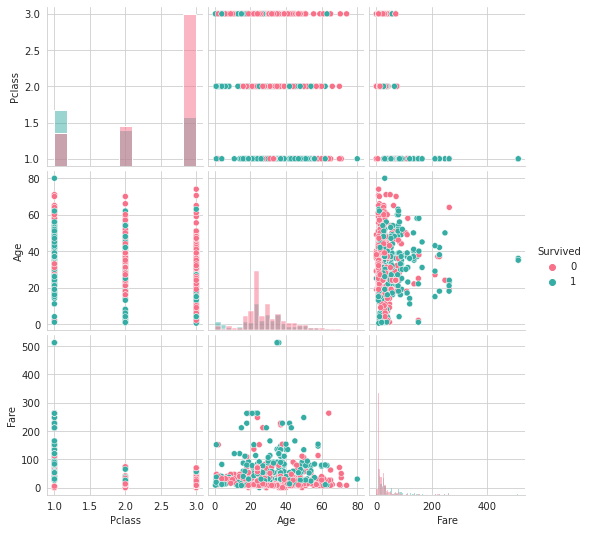

In [16]:
# 6. Pairplot of selected numerical variables
selected_cols = ['Survived', 'Pclass', 'Age', 'Fare']
sns.pairplot(df[selected_cols], hue='Survived', palette='husl', diag_kind='hist')
plt.show()

In [17]:
# 1. Descriptive statistics
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
PassengerId,891.0,NaN,NaN,NaN,446.0,257.353842,1.0,223.5,446.0,668.5,891.0
Survived,891.0,NaN,NaN,NaN,0.383838,0.486592,0.0,0.0,0.0,1.0,1.0
Pclass,891.0,NaN,NaN,NaN,2.308642,0.836071,1.0,2.0,3.0,3.0,3.0
Name,891,891,"Braund, Mr. Owen Harris",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Sex,891,2,male,577,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,891.0,NaN,NaN,NaN,29.066409,13.244532,0.42,22.0,26.0,37.0,80.0
SibSp,891.0,NaN,NaN,NaN,0.523008,1.102743,0.0,0.0,0.0,1.0,8.0
Parch,891.0,NaN,NaN,NaN,0.381594,0.806057,0.0,0.0,0.0,0.0,6.0
Ticket,891,681,347082,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fare,891.0,NaN,NaN,NaN,32.204208,49.693429,0.0,7.9104,14.4542,31.0,512.3292


In [18]:
# 2. Frequency distribution (categorical variables)
for col in ['Survived', 'Pclass', 'Sex', 'Embarked']:
    print(f"\nFrequency distribution for {col}:")
    print(df[col].value_counts())
    print(df[col].value_counts(normalize=True).round(3) * 100, "%")


Frequency distribution for Survived:
0    549
1    342
Name: Survived, dtype: int64
0    61.6
1    38.4
Name: Survived, dtype: float64 %

Frequency distribution for Pclass:
3    491
1    216
2    184
Name: Pclass, dtype: int64
3    55.1
1    24.2
2    20.7
Name: Pclass, dtype: float64 %

Frequency distribution for Sex:
male      577
female    314
Name: Sex, dtype: int64
male      64.8
female    35.2
Name: Sex, dtype: float64 %

Frequency distribution for Embarked:
S    646
C    168
Q     77
Name: Embarked, dtype: int64
S    72.5
C    18.9
Q     8.6
Name: Embarked, dtype: float64 %


In [19]:
# 3. Correlation analysis
corr_matrix = df.select_dtypes(include=[np.number]).corr()
corr_matrix

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Has_Cabin
PassengerId,1.000000,-0.005007,-0.035144,0.035840,-0.057527,-0.001652,0.012658,0.019919
Survived,-0.005007,1.000000,-0.338481,-0.047255,-0.035322,0.081629,0.257307,0.316912
Pclass,-0.035144,-0.338481,1.000000,-0.408487,0.083081,0.018443,-0.549500,-0.725541
Age,0.035840,-0.047255,-0.408487,1.000000,-0.243526,-0.171095,0.123784,0.276032
SibSp,-0.057527,-0.035322,0.083081,-0.243526,1.000000,0.414838,0.159651,-0.040460
Parch,-0.001652,0.081629,0.018443,-0.171095,0.414838,1.000000,0.216225,0.036987
Fare,0.012658,0.257307,-0.549500,0.123784,0.159651,0.216225,1.000000,0.482075
Has_Cabin,0.019919,0.316912,-0.725541,0.276032,-0.040460,0.036987,0.482075,1.000000


In [20]:
# 4 & 5. Strongest positive and negative correlations (excluding self-correlation of 1.0)
corr_unstacked = corr_matrix.unstack()
corr_unstacked = corr_unstacked[corr_unstacked != 1.0]
strongest_positive = corr_unstacked.idxmax(), corr_unstacked.max()
strongest_negative = corr_unstacked.idxmin(), corr_unstacked.min()

print(f"Strongest positive correlation: {strongest_positive[0]} = {strongest_positive[1]:.3f}")
print(f"Strongest negative correlation: {strongest_negative[0]} = {strongest_negative[1]:.3f}")

Strongest positive correlation: ('Fare', 'Has_Cabin') = 0.482
Strongest negative correlation: ('Pclass', 'Has_Cabin') = -0.726


In [21]:
# 1. Select suitable predictor variables
# We encode categorical variables and select features with plausible predictive value
ml_df = df.copy()

le_sex = LabelEncoder()
ml_df['Sex'] = le_sex.fit_transform(ml_df['Sex'])   # male=1, female=0 (alphabetical)

le_embarked = LabelEncoder()
ml_df['Embarked'] = le_embarked.fit_transform(ml_df['Embarked'])

features = ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Has_Cabin']
X = ml_df[features]
y = ml_df['Survived']

print("Selected predictor variables:", features)
print("Target variable: Survived")

Selected predictor variables: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Has_Cabin']
Target variable: Survived


In [22]:
# 2. Split the dataset into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training set size: {X_train.shape[0]} passengers")
print(f"Testing set size: {X_test.shape[0]} passengers")

Training set size: 712 passengers
Testing set size: 179 passengers


In [23]:
# 3. Train a Logistic Regression classifier
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
print("Model trained successfully.")

Model trained successfully.


In [24]:
# 4. Predict on the testing data
y_pred = model.predict(X_test)

Accuracy: 0.8101 (81.01%)

Confusion Matrix:
[[97 13]
 [21 48]]


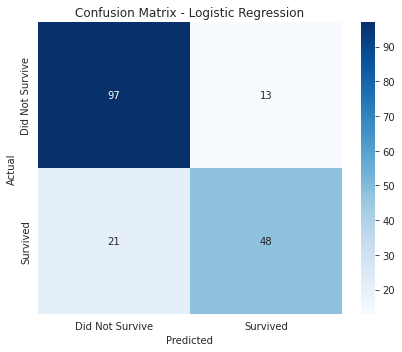


Classification Report:
                 precision    recall  f1-score   support

Did Not Survive       0.82      0.88      0.85       110
       Survived       0.79      0.70      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.79       179
   weighted avg       0.81      0.81      0.81       179



In [25]:
# 5. Compute Accuracy, Confusion Matrix, and Classification Report
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)")

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Did Not Survive', 'Survived'],
            yticklabels=['Did Not Survive', 'Survived'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

In [26]:
# Feature importance (coefficients) for interpretability
coef_df = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
coef_df

,Feature,Coefficient
1,Sex,-2.592183
0,Pclass,-0.870745
7,Has_Cabin,0.831350
3,SibSp,-0.257397
6,Embarked,-0.202835
4,Parch,-0.096228
2,Age,-0.042226
5,Fare,0.001243


In [ ]:
 Task 6: Discussion and Conclusion

Major Findings
Survival on the Titanic was strongly associated with passenger sex and class. Female passengers
and first-class passengers had markedly higher survival rates than male and third-class passengers.
This is reflected in the Logistic Regression model, where `Sex` (coefficient = -2.59) and `Pclass`
(coefficient = -0.87) were the two strongest predictors of survival, with being male and travelling
in a lower class both sharply reducing the odds of survival.

Statistical Insights
1) The strongest positive correlation in the dataset was between `Fare` and `Has_Cabin` (r = 0.48),
  showing that passengers who paid more were far more likely to have a recorded cabin.
2) The strongest negative correlation was between `Pclass` and `Has_Cabin` (r = -0.73), confirming
  that cabin allocation was almost entirely a first/second-class privilege.
3) `Pclass` also correlated negatively with `Survived` (r = -0.34), the strongest relationship any
  variable had with the survival outcome, reinforcing that class-based access (e.g., to lifeboats)
  played a major role in who survived.

Machine Learning Results
The Logistic Regression classifier achieved an accuracy of **81.01%** on the held-out test set (179
passengers). The confusion matrix showed the model correctly identified 97 of 110 non-survivors
(88% recall) and 48 of 69 survivors (70% recall), meaning the model is somewhat better at predicting
non-survival than survival likely because non-survivors were more common in the training data.
Precision and recall were both reasonably balanced (weighted average F1-score of 0.81), indicating a
generally reliable model given its simplicity.

Limitations of the Study
1) Missing `Age` values were imputed using the median age per passenger class rather than true
  observed values, introducing some estimation uncertainty.
2) The `Cabin` variable was too sparse (77% missing) to use directly, so it was reduced to a binary
  `Has_Cabin` flag, which may lose some finer-grained information.
3) Logistic Regression assumes a linear relationship between the predictors and the log-odds of
  survival, which may not capture more complex, non-linear interactions (e.g., between age and class).
4) The dataset is specific to the Titanic disaster, so findings should not be generalized to other
  maritime accidents or contexts without caution.

 Recommendations
1) Future work could compare Logistic Regression against more flexible models, such as Random Forest
  or Gradient Boosting, to test whether predictive accuracy improves.
2) Additional feature engineering for example, extracting passenger titles (Mr., Mrs., Master) from
  the `Name` column, or combining `SibSp` and `Parch` into a single family-size feature could improve
  model performance.
3) More advanced imputation methods (e.g., regression-based imputation) could be explored for `Age`
  instead of simple group-median filling.